# Step 1

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Load final datasets
anomaly_points = pd.read_csv("final_anomaly_points.csv")
actionable_events = pd.read_csv("final_actionable_events.csv")

anomaly_gdf = gpd.read_file("final_anomaly_points.geojson")
event_gdf = gpd.read_file("final_actionable_events.geojson")

print("========== FINAL FILES LOADED ==========")
print("Anomaly points:", len(anomaly_points))
print("Actionable events:", len(actionable_events))
print("Anomaly GeoDataFrame:", len(anomaly_gdf))
print("Event GeoDataFrame:", len(event_gdf))

print("\nAnomaly CRS:", anomaly_gdf.crs)
print("Event CRS:", event_gdf.crs)

========== FINAL FILES LOADED ==========
Anomaly points: 21
Actionable events: 6
Anomaly GeoDataFrame: 21
Event GeoDataFrame: 6

Anomaly CRS: EPSG:4326
Event CRS: EPSG:4326


# Final Anomaly Distribution Visualization

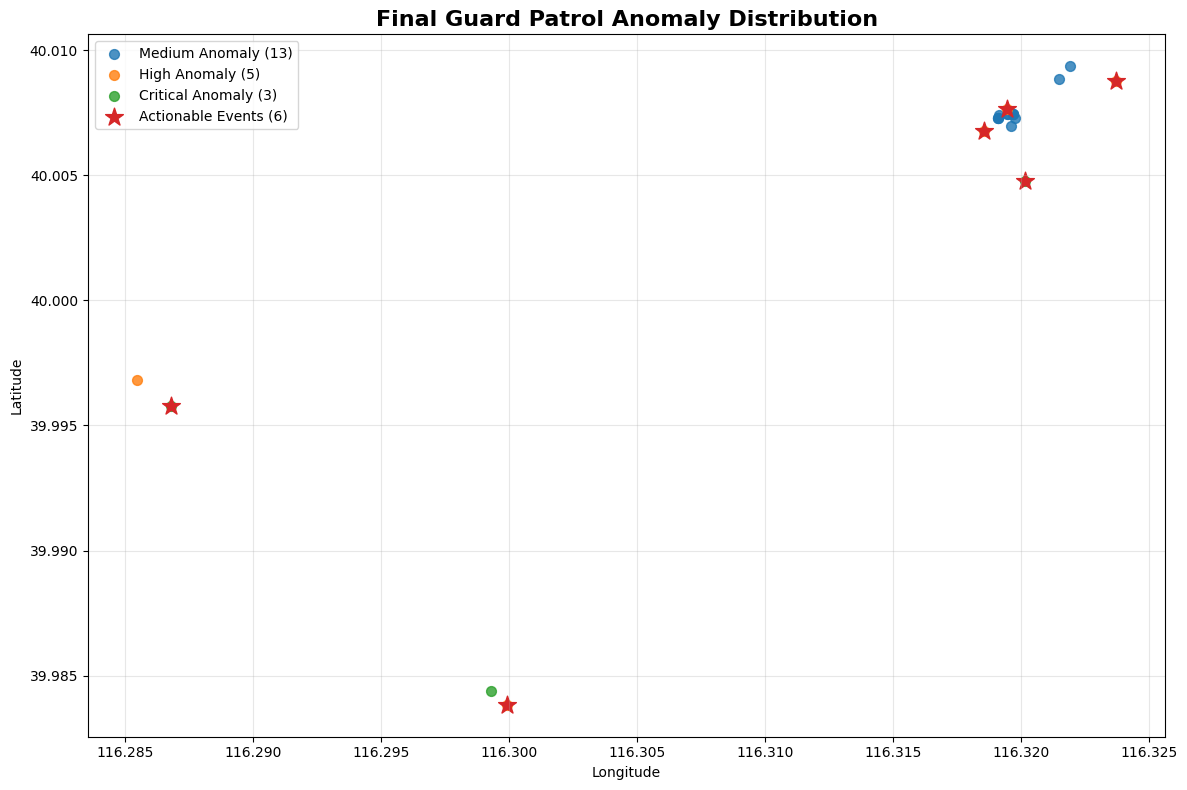

In [ ]:
#  Final anomaly distribution map

fig, ax = plt.subplots(figsize=(12, 8))

# Plot anomaly points by risk level
for risk in ["Medium", "High", "Critical"]:
    subset = anomaly_gdf[
        anomaly_gdf["final_risk_level"] == risk ]

    ax.scatter(
        subset.geometry.x,
        subset.geometry.y,
        s=50,
        label=f"{risk} Anomaly ({len(subset)})",
        alpha=0.8 )

# Plot actionable event locations
ax.scatter(
    event_gdf.geometry.x,
    event_gdf.geometry.y,
    marker="*",
    s=180,
    label=f"Actionable Events ({len(event_gdf)})")

ax.set_title(
    "Final Guard Patrol Anomaly Distribution",
    fontsize=16,
    fontweight="bold")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Risk Level Distribution

========== RISK LEVEL DISTRIBUTION ==========
final_risk_level
Medium      13
High         5
Critical     3
Name: count, dtype: int64


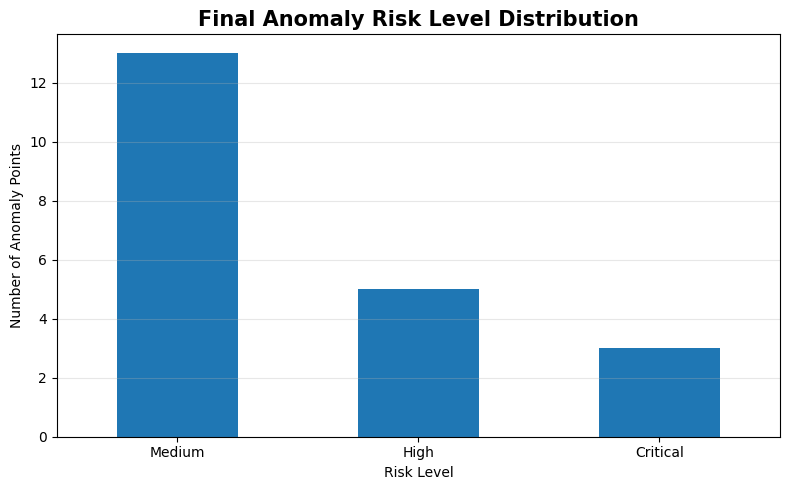

In [3]:
# Risk level distribution

risk_summary = (
    anomaly_gdf["final_risk_level"]
    .value_counts()
    .reindex(["Medium", "High", "Critical"], fill_value=0))

print("========== RISK LEVEL DISTRIBUTION ==========")
print(risk_summary)

plt.figure(figsize=(8, 5))

risk_summary.plot(
    kind="bar",
    figsize=(8, 5))

plt.title(
    "Final Anomaly Risk Level Distribution",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Risk Level")
plt.ylabel("Number of Anomaly Points")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Anomaly Reason Distribution

========== ANOMALY REASON DISTRIBUTION ==========
anomaly_reason
Far From Road                          11
Large Time Gap, Large Distance Jump     4
High Speed, Large Distance Jump         2
Large Distance Jump                     2
Large Time Gap                          2
Name: count, dtype: int64


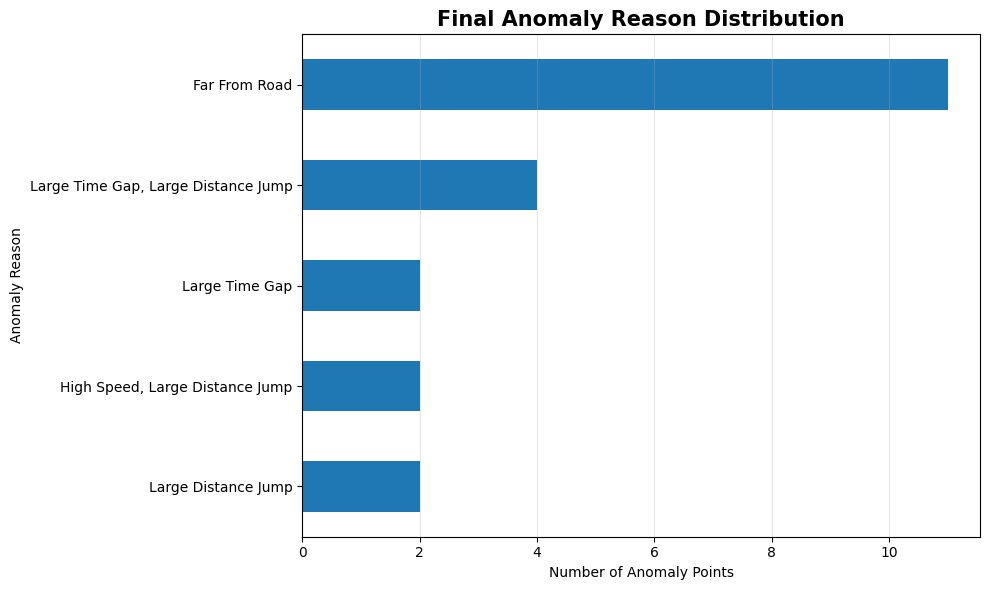

In [4]:
# Anomaly reason distribution

reason_summary = (
    anomaly_gdf["anomaly_reason"]
    .value_counts())

print("========== ANOMALY REASON DISTRIBUTION ==========")
print(reason_summary)

plt.figure(figsize=(10, 6))

reason_summary.sort_values().plot(
    kind="barh",
    figsize=(10, 6))

plt.title(
    "Final Anomaly Reason Distribution",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Number of Anomaly Points")
plt.ylabel("Anomaly Reason")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Patrol-wise Anomaly Distribution

========== PATROL-WISE ANOMALY DISTRIBUTION ==========
patrol_id
000_PATROL_0003    17
000_PATROL_0002     4
Name: count, dtype: int64


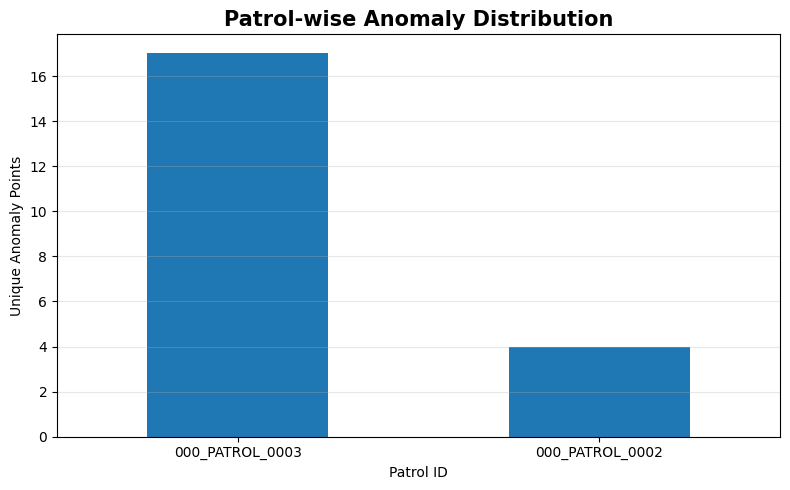

In [5]:
#  Patrol-wise anomaly distribution

patrol_summary = (
    anomaly_gdf["patrol_id"]
    .value_counts()
    .sort_values(ascending=False))

print("========== PATROL-WISE ANOMALY DISTRIBUTION ==========")
print(patrol_summary)

plt.figure(figsize=(8, 5))

patrol_summary.plot(
    kind="bar",
    figsize=(8, 5))

plt.title(
    "Patrol-wise Anomaly Distribution",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Patrol ID")
plt.ylabel("Unique Anomaly Points")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Strong vs Likely Anomaly Distribution

========== EVENT CLASSIFICATION DISTRIBUTION ==========
event_classification
Strong Anomaly    5
Likely Anomaly    1
Name: count, dtype: int64


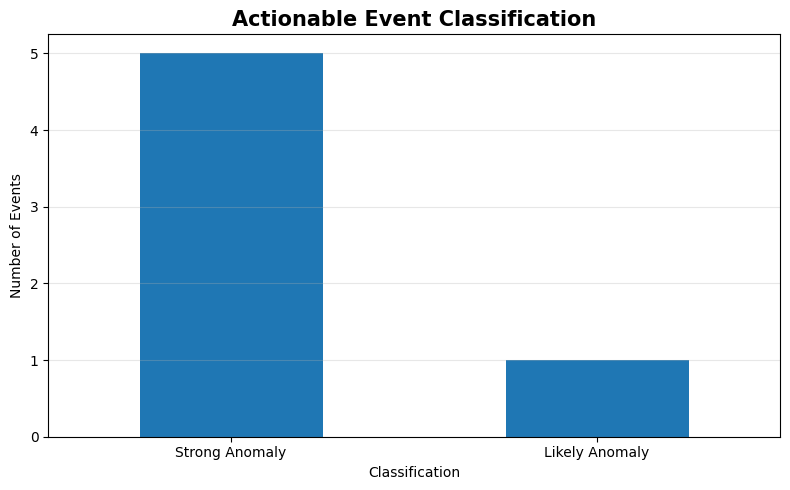

In [6]:
# Event classification distribution

classification_summary = (
    event_gdf["event_classification"]
    .value_counts()
    .reindex(
        ["Strong Anomaly", "Likely Anomaly"],
        fill_value=0 ))

print("========== EVENT CLASSIFICATION DISTRIBUTION ==========")
print(classification_summary)

plt.figure(figsize=(8, 5))

classification_summary.plot(
    kind="bar",
    figsize=(8, 5))

plt.title(
    "Actionable Event Classification",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Classification")
plt.ylabel("Number of Events")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Actionable Event Risk Distribution

========== ACTIONABLE EVENT RISK DISTRIBUTION ==========
event_risk_level
Critical    2
High        4
Medium      0
Name: count, dtype: int64


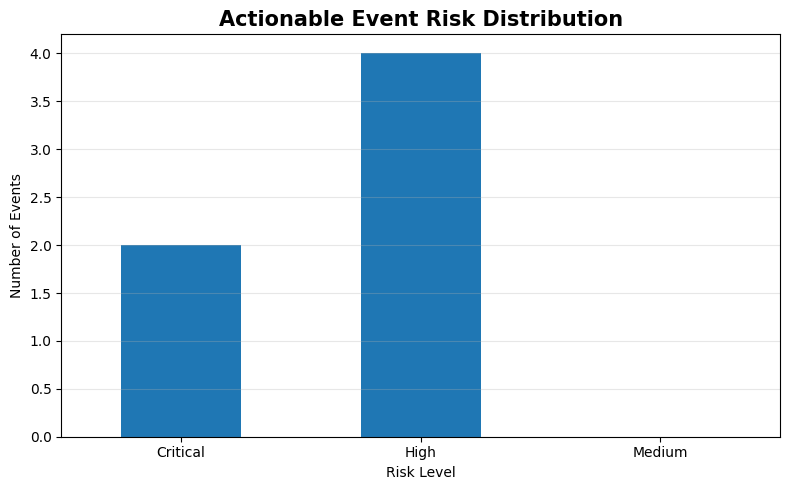

In [7]:
#  Actionable event risk distribution

event_risk_summary = (
    event_gdf["event_risk_level"]
    .value_counts()
    .reindex(
        ["Critical", "High", "Medium"],
        fill_value=0))

print("========== ACTIONABLE EVENT RISK DISTRIBUTION ==========")
print(event_risk_summary)

plt.figure(figsize=(8, 5))

event_risk_summary.plot(
    kind="bar",
    figsize=(8, 5))

plt.title(
    "Actionable Event Risk Distribution",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Risk Level")
plt.ylabel("Number of Events")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Hybrid Score Distribution

========== HYBRID SCORE SUMMARY ==========
Minimum score: 0.3601234036579988
Maximum score: 0.75
Mean score: 0.4994497340435238
Median score: 0.48391200906895526


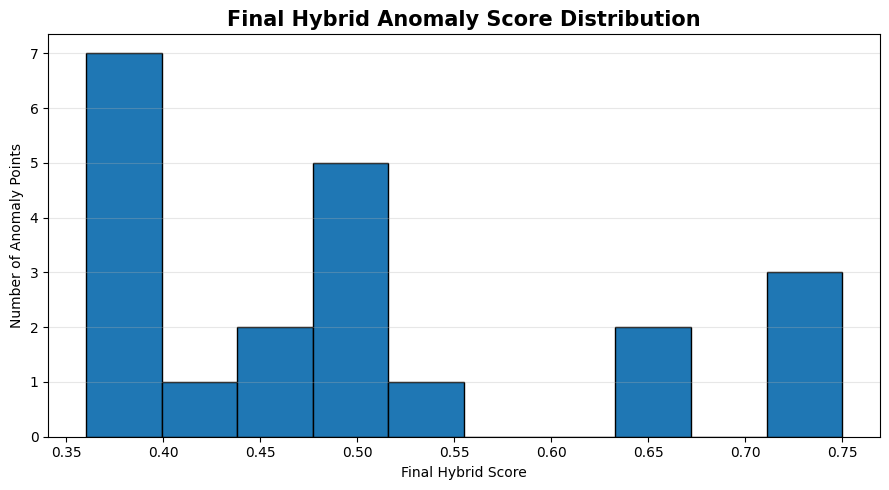

In [8]:
# Hybrid score distribution

score_data = anomaly_gdf["final_hybrid_score"].dropna()

print("========== HYBRID SCORE SUMMARY ==========")
print("Minimum score:", score_data.min())
print("Maximum score:", score_data.max())
print("Mean score:", score_data.mean())
print("Median score:", score_data.median())

plt.figure(figsize=(9, 5))

plt.hist(
    score_data,
    bins=10,
    edgecolor="black")

plt.title(
    "Final Hybrid Anomaly Score Distribution",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Final Hybrid Score")
plt.ylabel("Number of Anomaly Points")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Top 10 Highest-Risk Anomalies

In [9]:
# Top 10 highest-risk anomalies

top10_anomalies = (
    anomaly_gdf[
        [
            "patrol_id",
            "timestamp",
            "speed_kmh",
            "distance_from_previous_m",
            "distance_to_road_m",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason"
        ]
    ]
    .sort_values(
        "final_hybrid_score",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

print("========== TOP 10 HIGHEST-RISK ANOMALIES ==========")
print(top10_anomalies)

========== TOP 10 HIGHEST-RISK ANOMALIES ==========
         patrol_id           timestamp   speed_kmh  distance_from_previous_m  \
0  000_PATROL_0002 2008-10-23 04:08:07    1.577309               1652.669139   
1  000_PATROL_0002 2008-10-23 04:08:42  218.147174               1817.893113   
2  000_PATROL_0003 2008-10-23 09:42:25    0.134025                686.989499   
3  000_PATROL_0002 2008-10-23 04:08:12  118.423778                164.477469   
4  000_PATROL_0003 2008-10-23 10:26:35    2.561721                226.996955   
5  000_PATROL_0003 2008-10-23 10:44:31    0.654102                121.917427   
6  000_PATROL_0003 2008-10-23 10:19:16   61.286863                 85.120643   
7  000_PATROL_0002 2008-10-23 04:11:22   75.080580                104.278583   
8  000_PATROL_0003 2008-10-23 10:28:45   22.530987                 62.586075   
9  000_PATROL_0003 2008-10-23 11:08:22    0.032082                 11.861401   

   distance_to_road_m  final_hybrid_score final_risk_level  \
0    

# Visualization

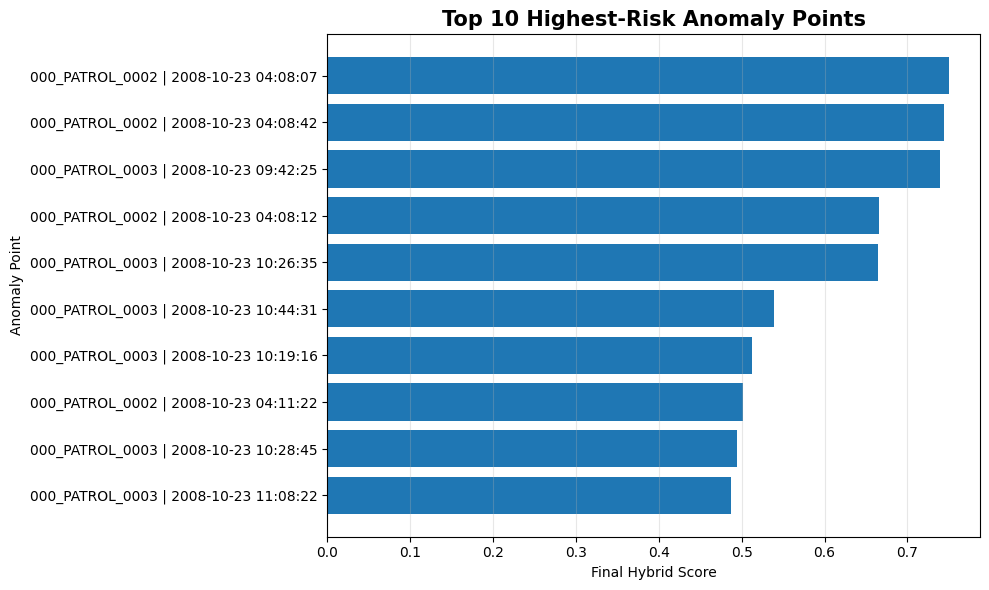

In [10]:
plt.figure(figsize=(10, 6))

plt.barh(
    range(len(top10_anomalies)),
    top10_anomalies["final_hybrid_score"])

plt.yticks(
    range(len(top10_anomalies)),
    [
        f"{p} | {t}"
        for p, t in zip(
            top10_anomalies["patrol_id"],
            top10_anomalies["timestamp"]
        )
    ])

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Highest-Risk Anomaly Points",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Final Hybrid Score")
plt.ylabel("Anomaly Point")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Actionable Events Priority Visualization

# Event Priority Table

In [11]:
# Actionable event priority ranking

event_priority = (
    event_gdf[
        [
            "patrol_id",
            "event_id",
            "event_risk_level",
            "event_classification",
            "max_hybrid_score",
            "description",
            "alert_status"
        ]
    ]
    .sort_values(
        "max_hybrid_score",
        ascending=False)
    .reset_index(drop=True))

print("========== ACTIONABLE EVENT PRIORITY ==========")
print(event_priority)

========== ACTIONABLE EVENT PRIORITY ==========
         patrol_id  event_id event_risk_level event_classification  \
0  000_PATROL_0002         1         Critical       Strong Anomaly   
1  000_PATROL_0003         1         Critical       Strong Anomaly   
2  000_PATROL_0003         7             High       Strong Anomaly   
3  000_PATROL_0003         9             High       Likely Anomaly   
4  000_PATROL_0003         6             High       Strong Anomaly   
5  000_PATROL_0002         2             High       Strong Anomaly   

   max_hybrid_score                                        description  \
0          0.750000  Extreme speed detected with a large distance j...   
1          0.738794  Large GPS displacement detected between consec...   
2          0.664662  Large distance jump detected between consecuti...   
3          0.539234  Multiple abnormal movement signals detected; m...   
4          0.512960            Unusually high movement speed detected.   
5          0.5010

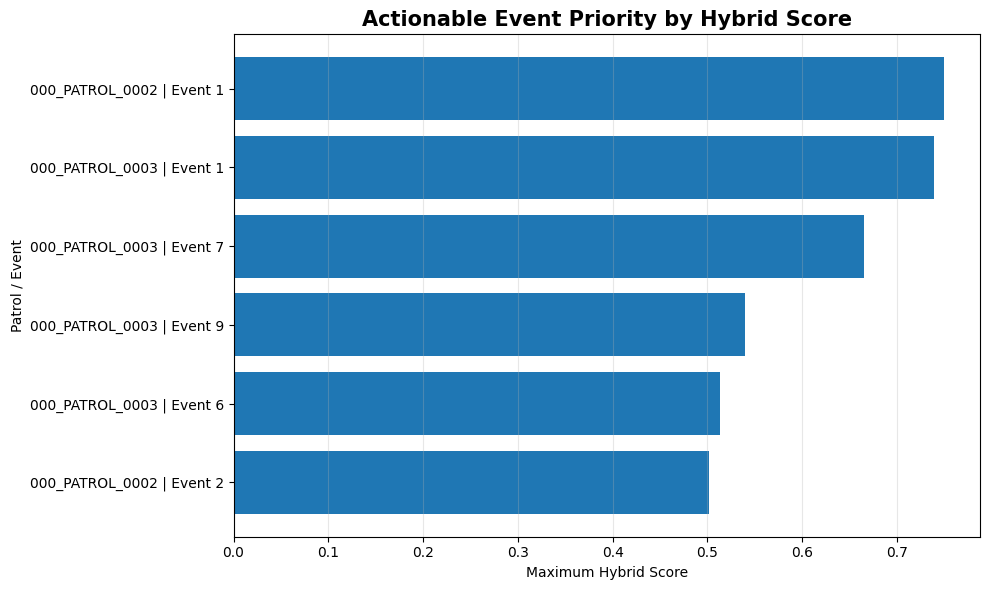

In [12]:
plt.figure(figsize=(10, 6))

plt.barh(
    range(len(event_priority)),
    event_priority["max_hybrid_score"]
)

plt.yticks(
    range(len(event_priority)),
    [
        f"{p} | Event {e}"
        for p, e in zip(
            event_priority["patrol_id"],
            event_priority["event_id"]
        )
    ]
)

plt.gca().invert_yaxis()

plt.title(
    "Actionable Event Priority by Hybrid Score",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Maximum Hybrid Score")
plt.ylabel("Patrol / Event")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Load Final Outputs

In [13]:
import pandas as pd
import geopandas as gpd

final_anomalies = pd.read_csv("final_anomaly_points.csv")
final_events = pd.read_csv("final_actionable_events.csv")

final_anomaly_gdf = gpd.read_file("final_anomaly_points.geojson")
final_event_gdf = gpd.read_file("final_actionable_events.geojson")

print("Anomaly points:", len(final_anomalies))
print("Actionable events:", len(final_events))
print("Anomaly CRS:", final_anomaly_gdf.crs)
print("Event CRS:", final_event_gdf.crs)

Anomaly points: 21
Actionable events: 6
Anomaly CRS: EPSG:4326
Event CRS: EPSG:4326


# Create Risk Distribution Chart

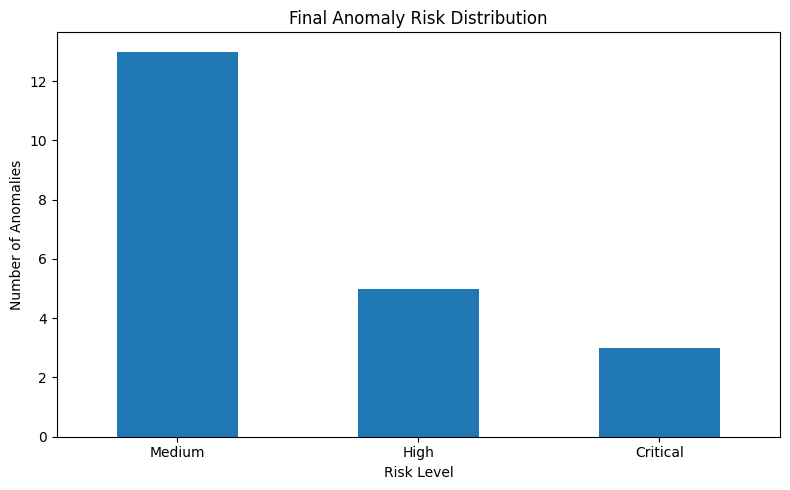

In [14]:
import matplotlib.pyplot as plt

risk_counts = final_anomalies["final_risk_level"].value_counts()

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")

plt.title("Final Anomaly Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Anomalies")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Create Actionable Event Chart

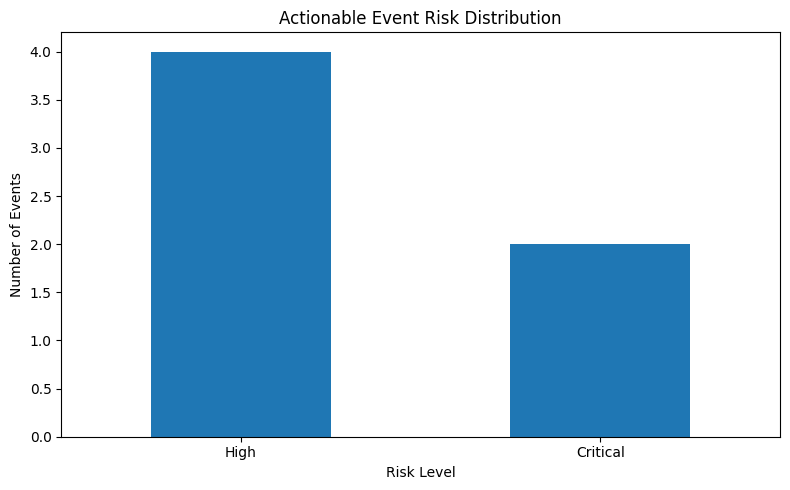

In [15]:
event_risk_counts = final_events["event_risk_level"].value_counts()

plt.figure(figsize=(8, 5))
event_risk_counts.plot(kind="bar")

plt.title("Actionable Event Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Patrol-wise Anomaly Chart

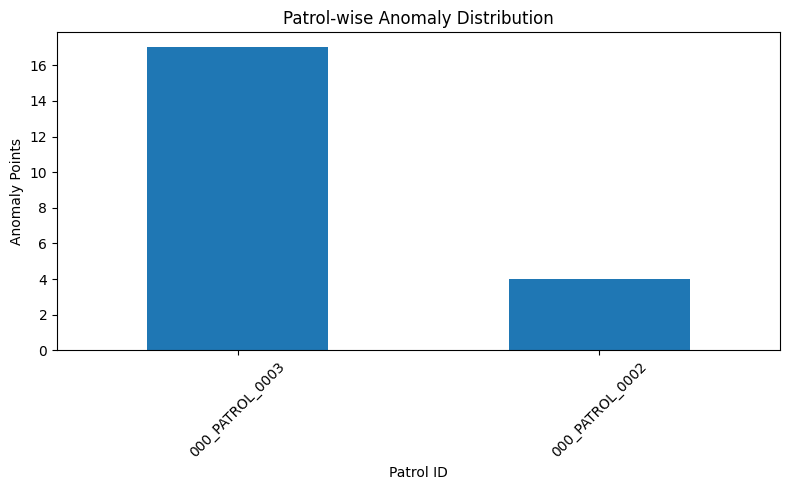

In [16]:
patrol_counts = final_anomalies["patrol_id"].value_counts()

plt.figure(figsize=(8, 5))
patrol_counts.plot(kind="bar")

plt.title("Patrol-wise Anomaly Distribution")
plt.xlabel("Patrol ID")
plt.ylabel("Anomaly Points")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create Final Anomaly Map

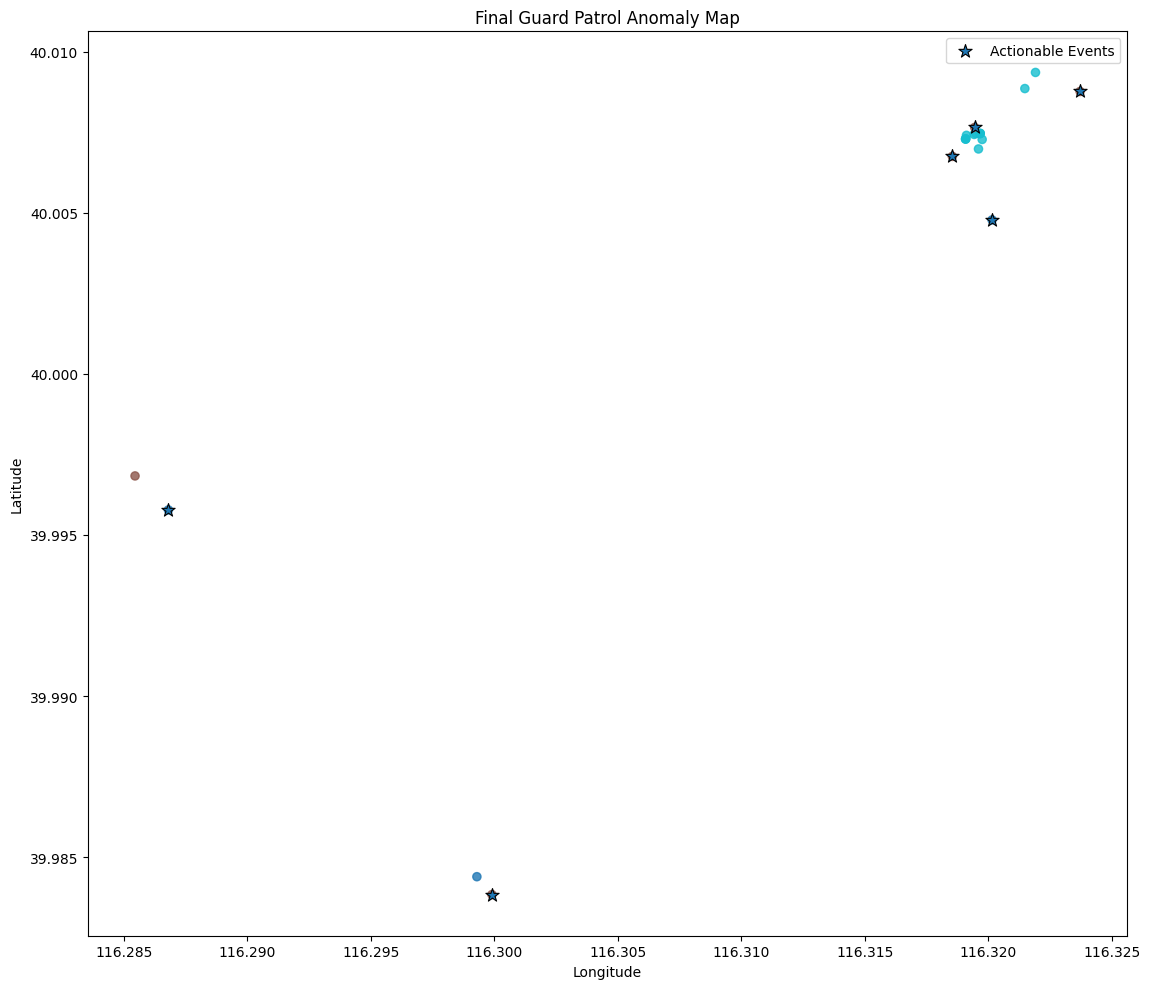

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

# Plot anomaly points
final_anomaly_gdf.plot(
    ax=ax,
    markersize=35,
    alpha=0.8,
    column="final_risk_level",
    legend=True
)

# Plot actionable event locations
final_event_gdf.plot(
    ax=ax,
    markersize=100,
    marker="*",
    edgecolor="black",
    linewidth=0.8,
    label="Actionable Events"
)

ax.set_title("Final Guard Patrol Anomaly Map")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend()

plt.tight_layout()
plt.show()

# Save the Final Map

In [18]:
plt.savefig(
    "final_guard_patrol_anomaly_map.png",
    dpi=300,
    bbox_inches="tight")

print("Final anomaly map saved successfully.")

Final anomaly map saved successfully.


<Figure size 640x480 with 0 Axes>

# Generate Final Executive Summary

In [ ]:
# Final Executive Summary

total_gps = 916
unique_anomalies = 21
actionable_events = 6

critical_events = (
    final_events["event_risk_level"] == "Critical"
).sum()

high_events = (
    final_events["event_risk_level"] == "High"
).sum()

strong_anomalies = (
    final_events["event_classification"] == "Strong Anomaly"
).sum()

likely_anomalies = (
    final_events["event_classification"] == "Likely Anomaly"
).sum()

anomaly_percentage = (
    unique_anomalies / total_gps
) * 100

print("========== FINAL EXECUTIVE SUMMARY ==========")
print(f"Total GPS points analyzed: {total_gps}")
print(f"Unique anomaly points: {unique_anomalies}")
print(f"Anomaly percentage: {anomaly_percentage:.2f}%")
print(f"Actionable events: {actionable_events}")
print(f"Critical events: {critical_events}")
print(f"High-risk events: {high_events}")
print(f"Strong anomalies: {strong_anomalies}")
print(f"Likely anomalies: {likely_anomalies}")

========== FINAL EXECUTIVE SUMMARY ==========
Total GPS points analyzed: 916
Unique anomaly points: 21
Anomaly percentage: 2.29%
Actionable events: 6
Critical events: 2
High-risk events: 4
Strong anomalies: 5
Likely anomalies: 1


# Create Final Project Metrics Table

In [20]:
#  Final Project Metrics

final_metrics = pd.DataFrame({
    "metric": [
        "Total GPS Points",
        "Unique Anomaly Points",
        "Anomaly Percentage",
        "Actionable Events",
        "Critical Events",
        "High-Risk Events",
        "Strong Anomalies",
        "Likely Anomalies"
    ],
    "value": [
        total_gps,
        unique_anomalies,
        f"{anomaly_percentage:.2f}%",
        actionable_events,
        critical_events,
        high_events,
        strong_anomalies,
        likely_anomalies
    ]
})

print("========== FINAL PROJECT METRICS ==========")
print(final_metrics)

========== FINAL PROJECT METRICS ==========
                  metric  value
0       Total GPS Points    916
1  Unique Anomaly Points     21
2     Anomaly Percentage  2.29%
3      Actionable Events      6
4        Critical Events      2
5       High-Risk Events      4
6       Strong Anomalies      5
7       Likely Anomalies      1


# Save Metrics

In [21]:
final_metrics.to_csv(
    "final_project_metrics.csv",
    index=False)

print("Final project metrics saved successfully.")

Final project metrics saved successfully.


# Generate Final Report

In [22]:
#  Generate Final Project Report

report = f"""
============================================================
       GUARD PATROL ANOMALY DETECTION - FINAL REPORT
============================================================

1. PROJECT OVERVIEW
-------------------
The system analyzes GPS guard patrol data and identifies
unusual movement patterns using a hybrid anomaly detection
approach combining rule-based detection and machine learning.

2. DATASET SUMMARY
------------------
Total GPS points analyzed: {total_gps}
Unique anomaly points: {unique_anomalies}
Anomaly percentage: {anomaly_percentage:.2f}%

3. ACTIONABLE EVENTS
--------------------
Total actionable events: {actionable_events}
Critical events: {critical_events}
High-risk events: {high_events}

4. EVENT CLASSIFICATION
-----------------------
Strong anomalies: {strong_anomalies}
Likely anomalies: {likely_anomalies}

5. ANOMALY REASONS
------------------
"""

reason_summary = final_anomalies["anomaly_reason"].value_counts()

for reason, count in reason_summary.items():
    report += f"- {reason}: {count} points\n"

report += """
6. PATROL-WISE ANOMALIES
------------------------
"""

patrol_summary = final_anomalies["patrol_id"].value_counts()

for patrol, count in patrol_summary.items():
    report += f"- {patrol}: {count} anomaly points\n"

report += """
7. RISK DISTRIBUTION
--------------------
"""

risk_summary = final_anomalies["final_risk_level"].value_counts()

for risk, count in risk_summary.items():
    report += f"- {risk}: {count} anomaly points\n"

report += f"""
8. MODEL SCORE
--------------
Minimum hybrid score: {final_anomalies["final_hybrid_score"].min():.4f}
Maximum hybrid score: {final_anomalies["final_hybrid_score"].max():.4f}
Mean hybrid score: {final_anomalies["final_hybrid_score"].mean():.4f}

9. FINAL VALIDATION
-------------------
Missing values: 0
Duplicate events: 0
Invalid geometry: 0
Empty geometry: 0
Missing coordinates: 0

10. CONCLUSION
--------------
The final hybrid anomaly detection system identified
{unique_anomalies} unique anomaly points from {total_gps}
GPS observations and grouped them into {actionable_events}
actionable events.

The final results indicate that the system can identify
high-risk patrol behavior and prioritize events for
operational review.

============================================================
                    END OF REPORT
============================================================
"""

print(report)


       GUARD PATROL ANOMALY DETECTION - FINAL REPORT

1. PROJECT OVERVIEW
-------------------
The system analyzes GPS guard patrol data and identifies
unusual movement patterns using a hybrid anomaly detection
approach combining rule-based detection and machine learning.

2. DATASET SUMMARY
------------------
Total GPS points analyzed: 916
Unique anomaly points: 21
Anomaly percentage: 2.29%

3. ACTIONABLE EVENTS
--------------------
Total actionable events: 6
Critical events: 2
High-risk events: 4

4. EVENT CLASSIFICATION
-----------------------
Strong anomalies: 5
Likely anomalies: 1

5. ANOMALY REASONS
------------------
- Far From Road: 11 points
- Large Time Gap, Large Distance Jump: 4 points
- High Speed, Large Distance Jump: 2 points
- Large Distance Jump: 2 points
- Large Time Gap: 2 points

6. PATROL-WISE ANOMALIES
------------------------
- 000_PATROL_0003: 17 anomaly points
- 000_PATROL_0002: 4 anomaly points

7. RISK DISTRIBUTION
--------------------
- Medium: 13 anomaly po

# Save Report 

In [23]:
# Save final report

with open("final_project_report.txt", "w", encoding="utf-8") as file:
    file.write(report)

print("Final project report saved successfully.")

Final project report saved successfully.


# Save Final Event Report

In [24]:
# Save actionable event report

final_events.to_csv(
    "final_actionable_event_report.csv",
    index=False)

print("Final actionable event report saved successfully.")

Final actionable event report saved successfully.


# FInal Output Files check 

In [ ]:
#  Final Output Files Validation

import os

required_files = [
    "final_anomaly_points.csv",
    "final_actionable_events.csv",
    "final_anomaly_points.geojson",
    "final_actionable_events.geojson",
    "final_guard_patrol_anomaly_map.png",
    "final_project_metrics.csv",
    "final_project_report.txt",
    "final_actionable_event_report.csv"
]

print("========== FINAL OUTPUT FILE CHECK ==========")

for file in required_files:
    if os.path.exists(file):
        print(f"✓ {file}")
    else:
        print(f"✗ MISSING: {file}")

========== FINAL OUTPUT FILE CHECK ==========
✓ final_anomaly_points.csv
✓ final_actionable_events.csv
✓ final_anomaly_points.geojson
✓ final_actionable_events.geojson
✓ final_guard_patrol_anomaly_map.png
✓ final_project_metrics.csv
✓ final_project_report.txt
✓ final_actionable_event_report.csv


# Final Dataset Integrity Check

In [ ]:
# Final Dataset Integrity

print("========== FINAL DATASET INTEGRITY ==========")

print("Anomaly points:", len(final_anomalies))
print("Actionable events:", len(final_events))

print(
    "Missing anomaly values:",
    final_anomalies.isna().sum().sum())

print(
    "Missing event values:",
    final_events.isna().sum().sum())

print(
    "Duplicate anomaly rows:",
    final_anomalies.duplicated().sum())

print(
    "Duplicate event rows:",
    final_events.duplicated().sum())

========== FINAL DATASET INTEGRITY ==========
Anomaly points: 21
Actionable events: 6
Missing anomaly values: 26


# Final Project Status 

In [ ]:
#  Final Project Status

print("""
====================================================
       GUARD PATROL ANOMALY DETECTION
                 PROJECT STATUS
====================================================

✓ Data Architecture
✓ Exploratory Data Analysis
✓ Data Cleaning
✓ Feature Engineering
✓ Rule-Based Anomaly Detection
✓ Isolation Forest Baseline
✓ Feature Preprocessing
✓ Hybrid Anomaly Detection
✓ Anomaly Validation
✓ Duplicate Handling
✓ Risk Scoring
✓ Event Grouping
✓ Actionable Event Generation
✓ Geospatial Validation
✓ Final Dataset Generation
✓ Final Visualization
✓ Final Metrics
✓ Final Report

STATUS: CORE PROJECT COMPLETE
====================================================
""")

In [5]:
from pathlib import Path

# Project root = one level above notebooks/
project_root = Path.cwd().parent

readme_path = project_root / "README.md"


In [6]:
print("README exists:", readme_path.exists())

print("\nProject root:")
for item in sorted(project_root.iterdir()):
    print(item.name)

README exists: True

Project root:
.env
.env.example
.git
.pytest_cache
.ruff_cache
.vscode
app
data
docs
logs
notebooks
README.md
tests
